In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from scipy.spatial import ConvexHull

from src.custom_functions import get_parameters_files, histogram_marginal, load_histogram, MSE, RMSE, histogram_CI_threshold, convex_hull_construction, histogram_marginal
from src.data_loader import load_data

import glob, pdb

densities = np.arange(10,22,2,dtype=int)  
x_d = np.arange(75, 1875.1, 50)
x_m = np.arange(62.5, 1900,  25)

fontsize=18
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

## Artificial data

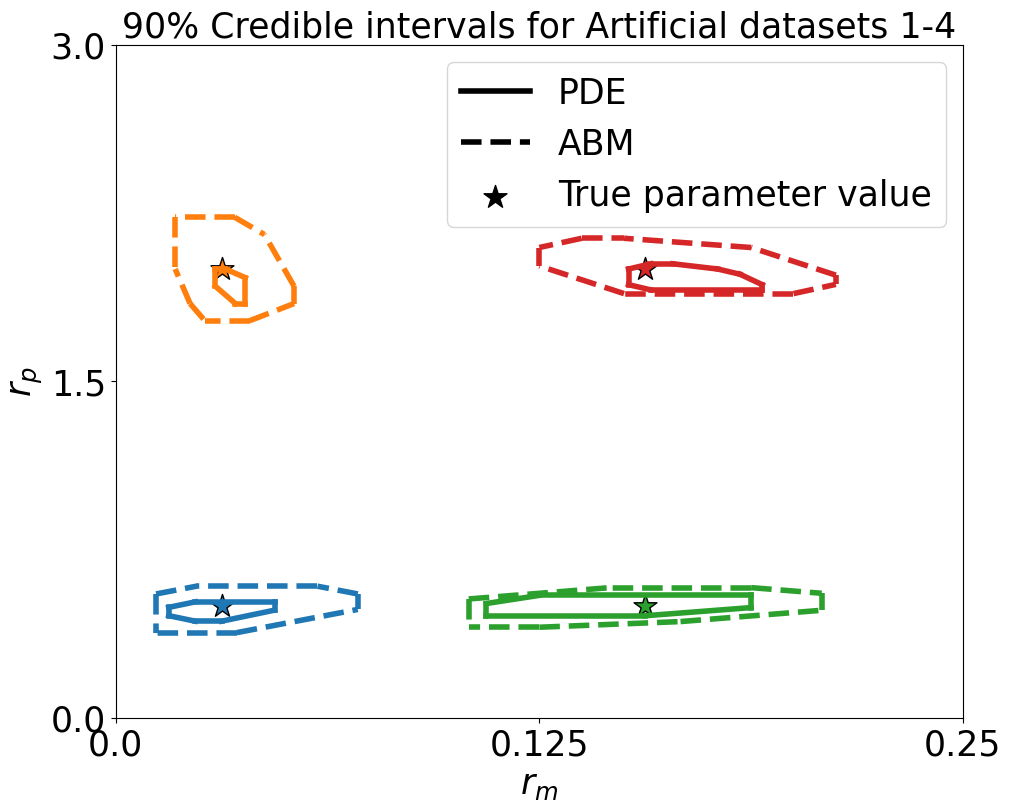

In [2]:
# Simulations 1-4

fontsize = 25

plt.figure(figsize=(10,8),layout="constrained")    
    
parameter_names = "rm_rp"#Model 1 
data_type = "artificial"
pred_type = "fit_all"

for simulation in range(4):

    for model_type in ["PDE","ABM"]:

        input_parameters = [None, parameter_names, model_type, data_type, simulation, pred_type]

        #Load in simulation information
        (parameter_names, 
        model_type, 
        data_type, 
        dens, 
        simulation,
        initial_perc,
        trueParams,
        delay, 
        lower_bounds,
        upper_bounds,
        indepParams,
        dxs,
        prediction_type,
        priorDir, 
        histogramDir, 
        posteriorDir) = get_parameters_files(input_parameters)

        #Load in histogram
        counts, edges, probabilities = load_histogram(histogramDir)

        param_1,param_2 = 0,1

        #Compute the marginal histogram
        (marginal_edges, 
         marginal_probabilities) = histogram_marginal(edges,probabilities,
                                                      (param_1,param_2))

        #Compute histogram centers and edges
        marginal_centers = [.5*(e[:-1]+e[1:]) for e in marginal_edges]
        marginal_Edges = np.meshgrid(*marginal_edges,indexing="ij")
        marginal_Centers = np.meshgrid(*marginal_centers,indexing="ij")

        #Determine threshold probability for 90% CI
        thres = histogram_CI_threshold(marginal_probabilities)
        CI = 1*(marginal_probabilities>=thres)

        #Compute convex hell
        hull,points = convex_hull_construction(CI,marginal_edges)

        #Plot true parameter
        if model_type=="PDE":
            plt.scatter(*trueParams,marker="*",color=colors[simulation],
                        s=300,edgecolors="k")

        if model_type == "PDE":
            linestyle="-"
        elif model_type=="ABM":
            linestyle="--"
        
        #plot convex hull
        for simplex in hull.simplices:
            plt.plot(points[simplex, 0],
                           points[simplex, 1],
                           color = colors[simulation],
                           linewidth = 4,
                           linestyle=linestyle) 
    

#plot
plt.title("90% Credible intervals for Artificial datasets 1-4",fontsize=fontsize)
plt.xlabel("",fontsize=fontsize)
plt.ylabel("",fontsize=fontsize)

plt.axis([lower_bounds[param_1],upper_bounds[param_1],
          lower_bounds[param_2],upper_bounds[param_2]])

plt.xticks([lower_bounds[param_1],.5*(lower_bounds[param_1]+upper_bounds[param_1]),upper_bounds[param_1]],
           [lower_bounds[param_1]*625/1e6,.5*(lower_bounds[param_1]+upper_bounds[param_1])*625/1e6,upper_bounds[param_1]*625/1e6],
          fontsize=fontsize)
plt.yticks([lower_bounds[param_2],.5*(lower_bounds[param_2]+upper_bounds[param_2]),upper_bounds[param_2]],
          fontsize=fontsize)

plt.plot([],[],"k-",linewidth=4,label="PDE")
plt.plot([],[],"k--",linewidth=4,label="ABM")
plt.xlabel("$r_m$",fontsize=fontsize)
plt.ylabel("$r_p$",fontsize=fontsize)
plt.scatter([],[],marker="*",c="k",s=300,label="True parameter value")
plt.legend(fontsize=fontsize)

plt.savefig(f"../../results/Figures/CI_artificial_sims_1_to_4.png")

In [3]:
def plot_marginal_distribution(probabilities, edges, model_type, fig=None, axes=None, trueParams = None):
    
    numParams = len(edges)

    fontsize=20
    
    if model_type == "ABM":
        linestyle = "--"
    elif model_type == "PDE":
        linestyle = "-"
    
    if fig is None:
        fig,axes = plt.subplots(numParams,numParams,figsize=(10,10))

    for j in range(1, numParams):
        for i in range(numParams-1):

            #Compute the marginal histogram
            (marginal_edges, 
             marginal_probabilities) = histogram_marginal(edges,probabilities, (i,j))
            
            #Compute histogram centers and edges
            marginal_centers = [.5*(e[:-1]+e[1:]) for e in marginal_edges]
            
            if i<j:

                #Determine threshold probability for 90% CI
                marginal_Centers = np.meshgrid(*marginal_centers,indexing="ij")
                marginal_Edges = np.meshgrid(*marginal_edges,indexing="ij")
                
                thres = histogram_CI_threshold(marginal_probabilities)
                CI = 1*(marginal_probabilities>=thres)
                
                #Compute convex hell
                hull,points = convex_hull_construction(CI,marginal_edges)
                
                #plot convex hull
                for simplex in hull.simplices:
                    axes[j-1,i].plot(points[simplex, 0],
                                   points[simplex, 1],
                                   color = "k",
                                   linestyle=linestyle,
                                    linewidth=4) 
                if trueParams is not None:
                    axes[j-1,i].scatter(trueParams[i],trueParams[j],
                                      marker="*",c="b",s = 200,zorder=10)
            else:
                axes[j-1,i].axis("off")
                
    return fig,axes

def subplot_axes(axes,parameter_names_list,lower_bounds,upper_bounds):
    
    numParams = len(indepParams)
    for j in range(numParams-1):
        axes[j,0].set_ylabel(parameter_names_list[j+1],fontsize=fontsize)    
        
    for i in range(numParams-1):
        axes[-1,i].set_xlabel(parameter_names_list[i],fontsize=fontsize)
    
    
    for i in range(numParams-1):
        for j in range(i+1):
            axes[i,j].axis( [lower_bounds[j]-.01*(upper_bounds[j]-lower_bounds[j]),
                             upper_bounds[j]+.01*(upper_bounds[j]-lower_bounds[j]),
                             lower_bounds[i+1]-.01*(upper_bounds[i+1]-lower_bounds[i+1]),
                             upper_bounds[i+1]+.01*(upper_bounds[i+1]-lower_bounds[i+1])] )
    
    return axes

def set_axis_bounds(ax,i,j,lower_bounds,upper_bounds,modify_x=False):

    if modify_x:
        ax.set_xticks([lower_bounds[i], .5*(lower_bounds[i] + upper_bounds[i]), upper_bounds[i]],
                  [lower_bounds[i], .5*(lower_bounds[i] + upper_bounds[i]*625/1e6), upper_bounds[i]*625/1e6],
                 fontsize=.75*fontsize)
    else:
        ax.set_xticks([lower_bounds[i], .5*(lower_bounds[i] + upper_bounds[i]), upper_bounds[i]],
                  [lower_bounds[i], .5*(lower_bounds[i] + upper_bounds[i]), upper_bounds[i]],
                 fontsize=.75*fontsize)
        
    ax.set_yticks([lower_bounds[j], .5*(lower_bounds[j] + upper_bounds[j]), upper_bounds[j]],
                  [lower_bounds[j], .5*(lower_bounds[j] + upper_bounds[j]), upper_bounds[j]],
                 fontsize=.75*fontsize)
    
    return ax

def label_axes(axes,display_names):
    
    num_vars = len(display_names)
    
    #label x-axes
    for i in range(num_vars-1):
        ax = axes[-1,i]
        ax.set_xlabel(display_names[i],fontsize=fontsize)
        
    #label y-axes
    for i in range(num_vars-1):
        ax = axes[i,0]
        ax.set_ylabel(display_names[i+1],fontsize=fontsize)



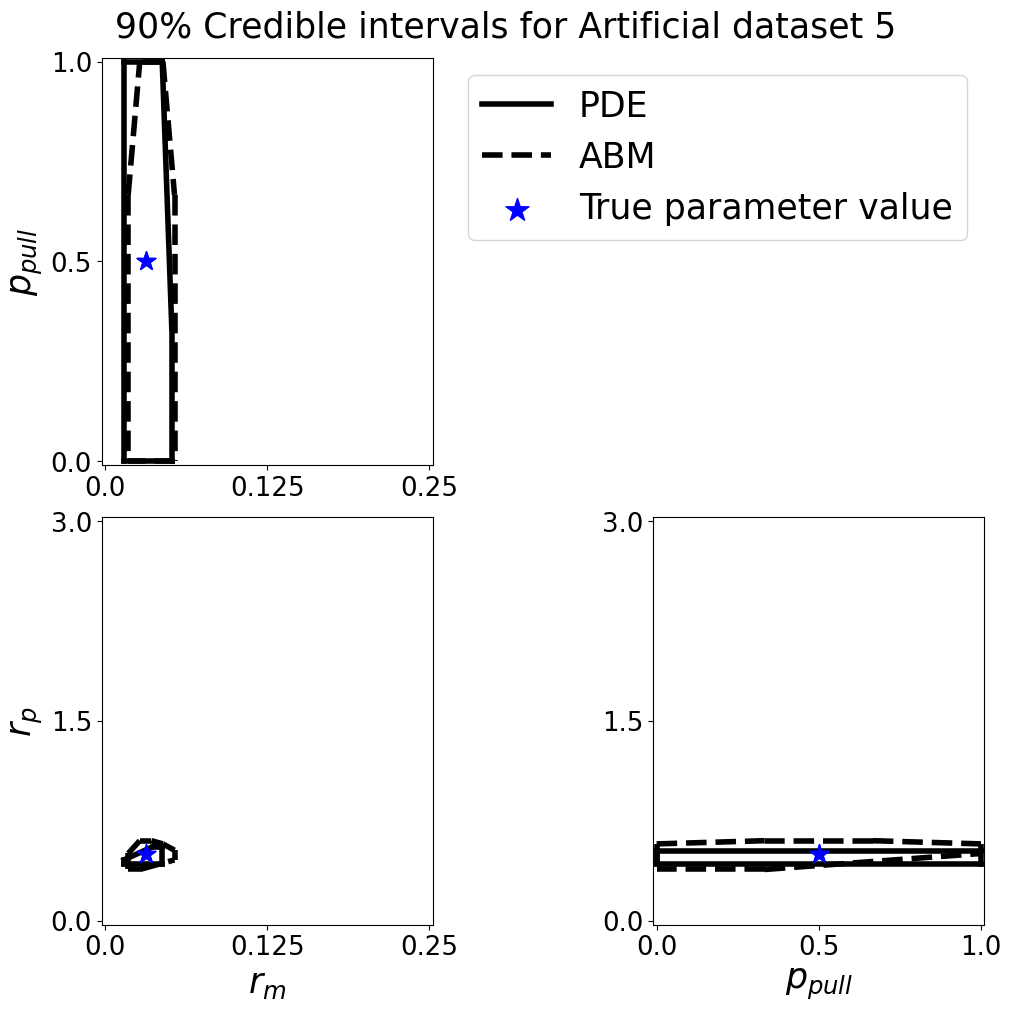

In [4]:
# Simulation 5

parameter_names = "rm_pint_rp" #Model 2
data_type = "artificial"
pred_type = "fit_all"
simulation = 4

num_params = parameter_names.count("_") + 1
fig,axes = plt.subplots(num_params-1,num_params-1,figsize=(10,10),layout="constrained")

for model_type in ["PDE","ABM"]:

    input_parameters = [None, parameter_names, model_type, data_type, simulation, pred_type]

    #Load in simulation information
    (parameter_names, 
    model_type, 
    data_type, 
    dens, 
    simulation,
    initial_perc,
    trueParams,
    delay, 
    lower_bounds,
    upper_bounds,
    indepParams,
    dxs,
    prediction_type,
    priorDir, 
    histogramDir, 
    posteriorDir) = get_parameters_files(input_parameters)
    
    if model_type == "ABM":
        posteriorDir = posteriorDir[:-1] + "_individual_testing/"
        
    #Load in histogram
    counts, edges, probabilities = load_histogram(histogramDir)
    
    fig,axes = plot_marginal_distribution(probabilities,edges,model_type,fig,axes,trueParams)
    
    axes = subplot_axes(axes,parameter_names.split("_"),lower_bounds,upper_bounds)

#plot
ax = axes[0,1]
fontsize = 25
ax.plot([],[],"k-",linewidth=4,label="PDE")
ax.plot([],[],"k--",linewidth=4,label="ABM")
ax.scatter([],[],marker="*",c="b",s=300,label="True parameter value")
ax.legend(fontsize=fontsize)

num_vars = parameter_names.count("_")+1
display_names = ["$r_m$","$p_{pull}$","$r_p$"]

for i in range(num_vars):
    for j in range(i + 1, num_vars):
        # Map the sequential pairs to the correct subplot grid coordinates
        # Your mapping: (0,1) -> [0,0]; (0,2) -> [1,0]; (1,2) -> [1,1]
        row_idx = j - 1
        col_idx = i
        
        ax = axes[row_idx, col_idx]
        modify_x = (i == 0)
        
        # Apply the function
        _ = set_axis_bounds(ax, i, j, lower_bounds, upper_bounds, modify_x=modify_x)

label_axes(axes,display_names)

plt.suptitle("90% Credible intervals for Artificial dataset 5",fontsize=fontsize);
plt.savefig(f"../../results/Figures/CI_artificial_sim_5.png")

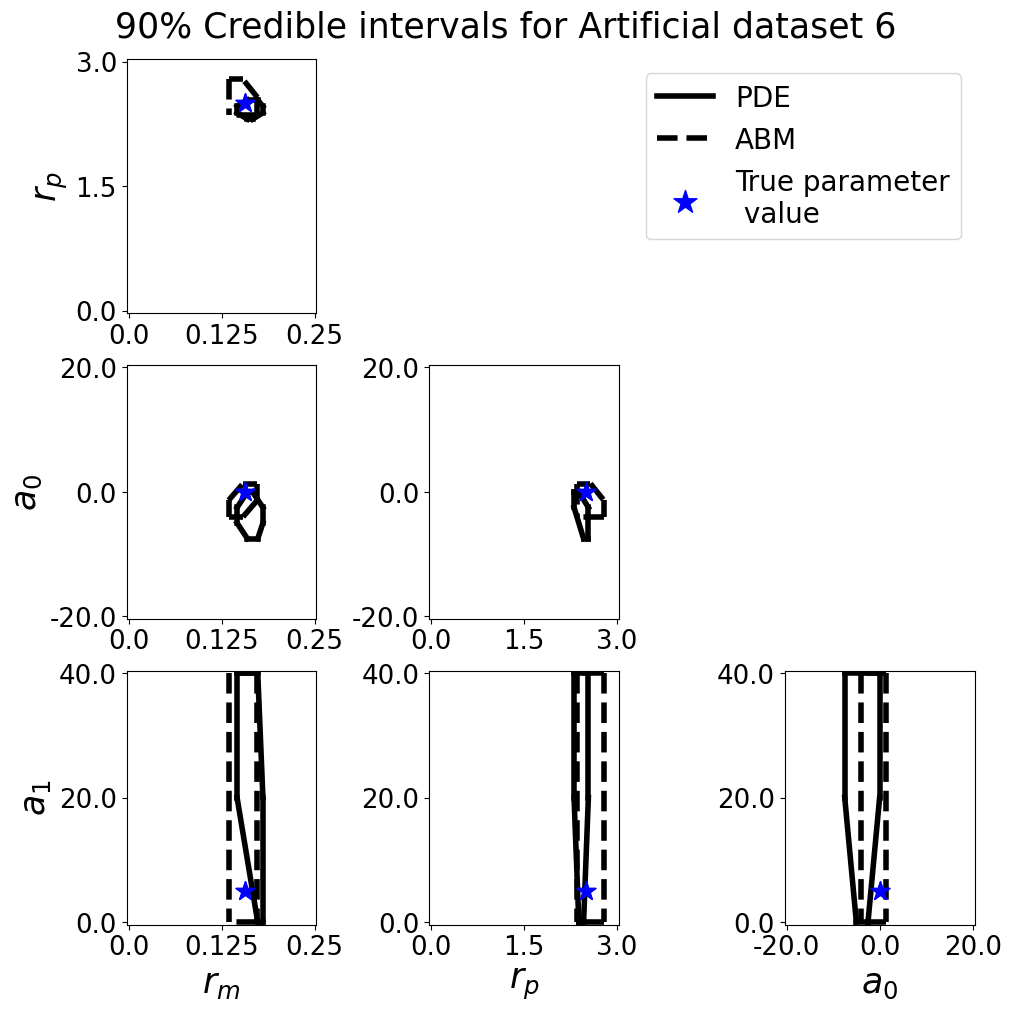

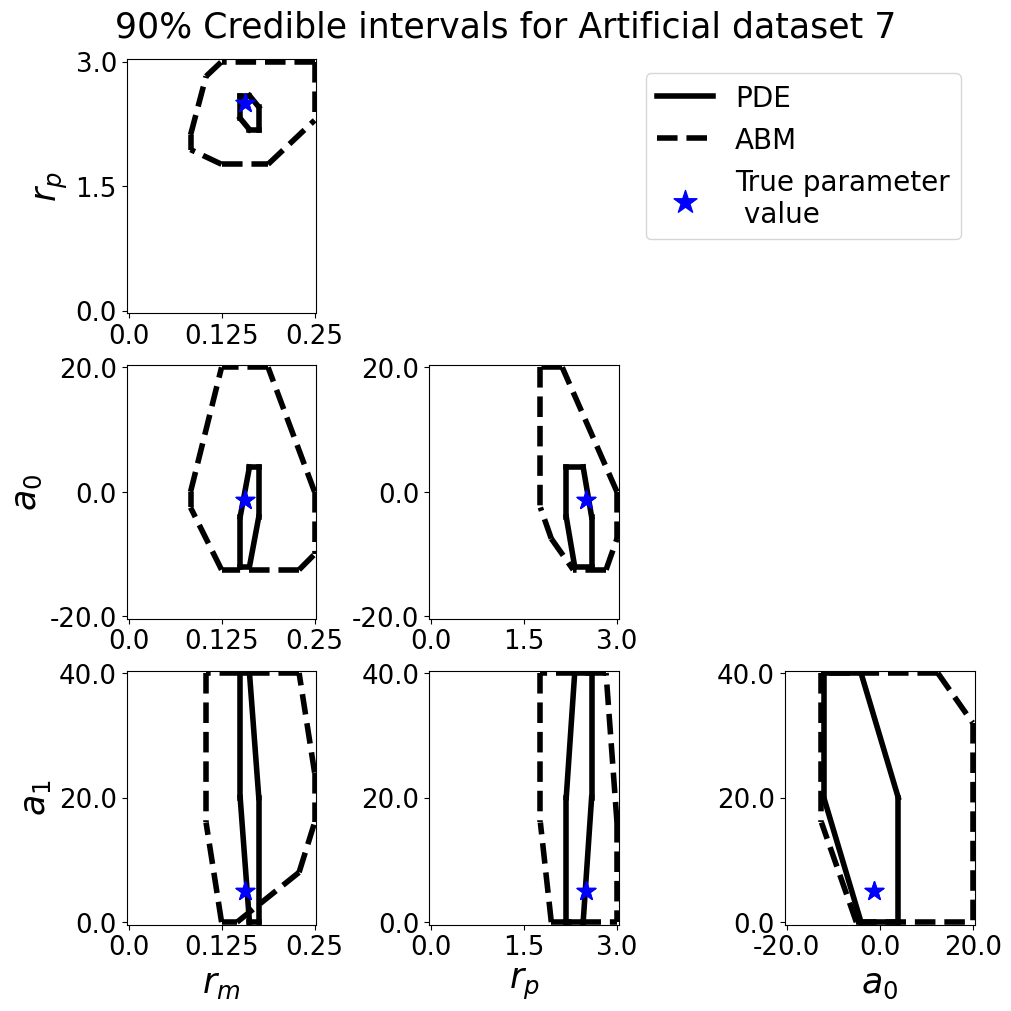

In [5]:
#Simulations 6,7

parameter_names = "rm_rp_a0_a1"  #Model 3
data_type = "artificial"
pred_type = "fit_all"

for simulation in [5,6]:

    num_params = parameter_names.count("_") + 1
    fig,axes = plt.subplots(num_params-1,num_params-1,figsize=(10,10),layout="constrained")

    for model_type in ["PDE","ABM"]:

        input_parameters = [None, parameter_names, model_type, data_type, simulation, pred_type]

        #Load in simulation information
        (parameter_names, 
        model_type, 
        data_type, 
        dens, 
        simulation,
        initial_perc,
        trueParams,
        delay, 
        lower_bounds,
        upper_bounds,
        indepParams,
        dxs,
        prediction_type,
        priorDir, 
        histogramDir, 
        posteriorDir) = get_parameters_files(input_parameters)

        if model_type == "ABM":
            posteriorDir = posteriorDir[:-1] + "_individual_testing/"

        #Load in histogram
        counts, edges, probabilities = load_histogram(histogramDir)

        fig,axes = plot_marginal_distribution(probabilities,edges,model_type,fig,axes,trueParams)

        axes = subplot_axes(axes,parameter_names.split("_"),lower_bounds,upper_bounds)

    ax = axes[0,-1]
    ax.plot([],[],"k-",linewidth=4,label="PDE")
    ax.plot([],[],"k--",linewidth=4,label="ABM")
    ax.scatter([],[],marker="*",c="b",s=300,label="True parameter\n value")
    ax.legend(fontsize=.8*fontsize)

    num_vars = parameter_names.count("_")+1
    display_names = ["$r_m$","$r_p$","$a_0$","$a_1$"]

    for i in range(num_vars):
        for j in range(i + 1, num_vars):
            # Map the sequential pairs to the correct subplot grid coordinates
            # Your mapping: (0,1) -> [0,0]; (0,2) -> [1,0]; (1,2) -> [1,1]
            row_idx = j - 1
            col_idx = i

            ax = axes[row_idx, col_idx]
            modify_x = (i == 0)

            # Apply the function
            _ = set_axis_bounds(ax, i, j, lower_bounds, upper_bounds, modify_x=modify_x)

    label_axes(axes,display_names)

    plt.suptitle(f"90% Credible intervals for Artificial dataset {simulation+1}",fontsize=fontsize);
    plt.savefig(f"../../results/Figures/CI_artificial_sim_{simulation+1}.png")    

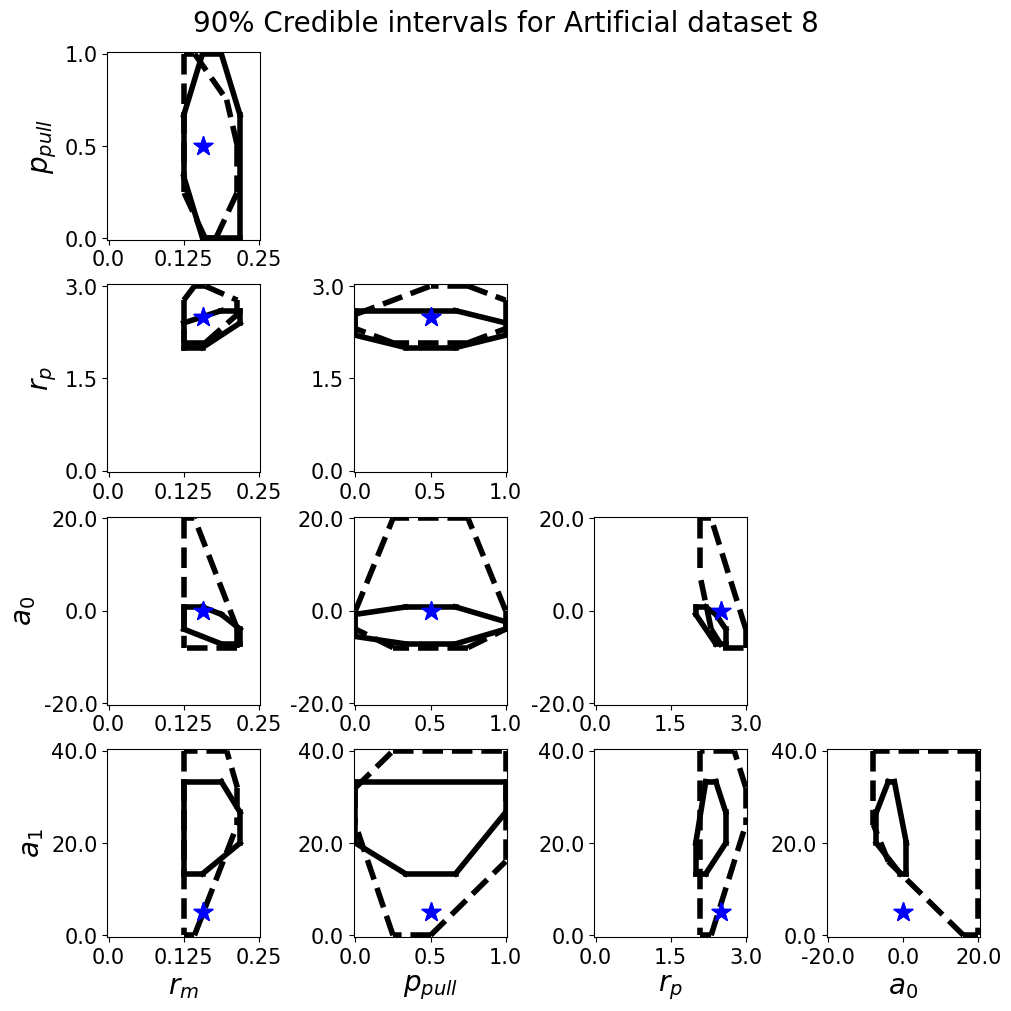

In [6]:
# Simulation 8

parameter_names = "rm_pint_rp_a0_a1" #Model 4
data_type = "artificial"
pred_type = "fit_all"
simulation = 7

num_params = parameter_names.count("_") + 1
fig,axes = plt.subplots(num_params-1,num_params-1,figsize=(10,10),layout="constrained")

for model_type in ["PDE","ABM"]:

    input_parameters = [None, parameter_names, model_type, data_type, simulation, pred_type]

    #Load in simulation information
    (parameter_names, 
    model_type, 
    data_type, 
    dens, 
    simulation,
    initial_perc,
    trueParams,
    delay, 
    lower_bounds,
    upper_bounds,
    indepParams,
    dxs,
    prediction_type,
    priorDir, 
    histogramDir, 
    posteriorDir) = get_parameters_files(input_parameters)
    
    if model_type == "ABM":
        posteriorDir = posteriorDir[:-1] + "_individual_testing/"

    #Load in histogram
    counts, edges, probabilities = load_histogram(histogramDir)
    
    fig,axes = plot_marginal_distribution(probabilities,edges,model_type,fig,axes,trueParams)
    
    axes = subplot_axes(axes,parameter_names.split("_"),lower_bounds,upper_bounds)

fontsize=20    
ax = axes[0,-1]
ax.plot([],[],"k-",linewidth=4,label="PDE")
ax.plot([],[],"k--",linewidth=4,label="ABM")
ax.scatter([],[],marker="*",c="b",s=300,label="True\nparameter\nvalue")
# ax.legend(fontsize=fontsize)

num_vars = parameter_names.count("_")+1
display_names = ["$r_m$","$p_{pull}$","$r_p$","$a_0$","$a_1$"]

for i in range(num_vars):
    for j in range(i + 1, num_vars):
        # Map the sequential pairs to the correct subplot grid coordinates
        # Your mapping: (0,1) -> [0,0]; (0,2) -> [1,0]; (1,2) -> [1,1]
        row_idx = j - 1
        col_idx = i
        
        ax = axes[row_idx, col_idx]
        modify_x = (i == 0)
        
        # Apply the function
        _ = set_axis_bounds(ax, i, j, lower_bounds, upper_bounds, modify_x=modify_x)

label_axes(axes,display_names)


plt.suptitle(f"90% Credible intervals for Artificial dataset {simulation+1}",fontsize=fontsize);
plt.savefig(f"../../results/Figures/CI_artificial_sim_{simulation+1}.png")        

## Wound healing data

In [7]:
def plot_marginal_distribution(probabilities, edges, density, fig=None, axes=None, trueParams = None):
    
    numParams = len(edges)

    fontsize=20
    
    if density == 12:
        color="blue"
    elif density == 16:
        color="green"
    elif density == 20:
        color="orange"
    
    for j in range(1, numParams):
        for i in range(numParams-1):

            #Compute the marginal histogram
            (marginal_edges, 
             marginal_probabilities) = histogram_marginal(edges,probabilities, (i,j))
            
            #Compute histogram centers and edges
            marginal_centers = [.5*(e[:-1]+e[1:]) for e in marginal_edges]
            
            if i<j:

                marginal_Centers = np.meshgrid(*marginal_centers,indexing="ij")
                marginal_Edges = np.meshgrid(*marginal_edges,indexing="ij")
                
                #Determine threshold probability for 90% CI
                thres = histogram_CI_threshold(marginal_probabilities)
                # if thres == 0.01:
                #     thres = 0.02
                CI = 1*(marginal_probabilities>=thres)
                
                #Compute convex hell
                hull,points = convex_hull_construction(CI,marginal_edges)
                
                #plot convex hull
                for simplex in hull.simplices:
                    axes[j-1,i].plot(points[simplex, 0],
                                   points[simplex, 1],
                                   color = color,
                                   linestyle="-", linewidth=4) 
                # axes[j,i].pcolor(*marginal_Edges,marginal_probabilities)
                
                
            else:
                axes[j-1,i].axis("off")
                
    return fig,axes



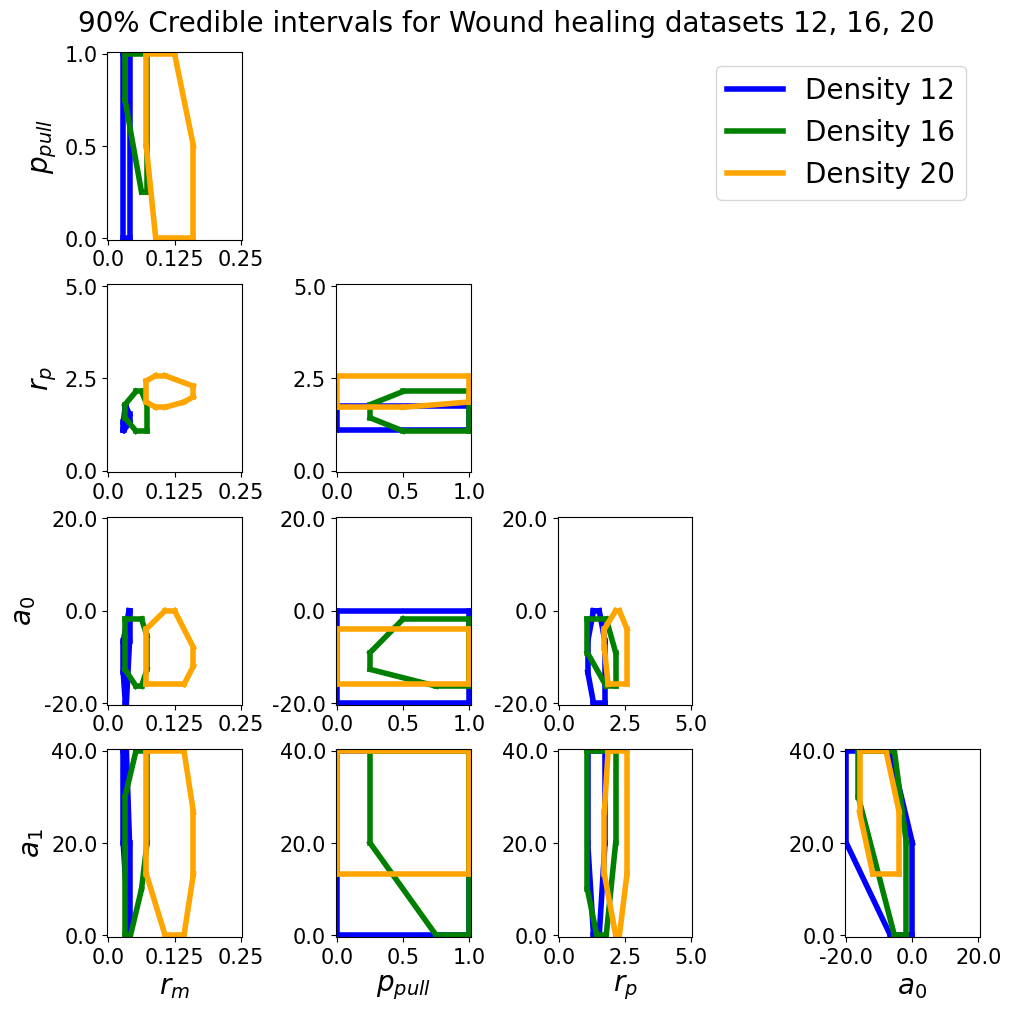

In [8]:
parameter_names = "rm_pint_rp_a0_a1" #Model 4
data_type = "WH"
pred_type = "fit_all"
density_ids = [1,3,5]
model_type = "PDE"

num_params = parameter_names.count("_") + 1
fig,axes = plt.subplots(num_params-1,num_params-1,figsize=(10,10),layout="constrained")

for dens_id in density_ids:

    input_parameters = [None, parameter_names, model_type, data_type, dens_id, pred_type]

    #Load in simulation information
    (parameter_names, 
    model_type, 
    data_type, 
    dens, 
    simulation,
    initial_perc,
    trueParams,
    delay, 
    lower_bounds,
    upper_bounds,
    indepParams,
    dxs,
    prediction_type,
    priorDir, 
    histogramDir, 
    posteriorDir) = get_parameters_files(input_parameters)
    
    if model_type == "ABM":
        posteriorDir = posteriorDir[:-1] + "_individual_testing/"

    #Load in histogram
    counts, edges, probabilities = load_histogram(histogramDir)
    
    fig,axes = plot_marginal_distribution(probabilities,edges,dens,fig,axes,trueParams)
    
    axes = subplot_axes(axes,parameter_names.split("_"),lower_bounds,upper_bounds)

fontsize=20  
ax = axes[0,-1]
ax.plot([],[],"b-",linewidth=4,label="Density 12")
ax.plot([],[],"g-",linewidth=4,label="Density 16")
ax.plot([],[],"-",color="orange",linewidth=4,label="Density 20")
ax.legend(fontsize=fontsize)

num_vars = parameter_names.count("_")+1
display_names = ["$r_m$","$p_{pull}$","$r_p$","$a_0$","$a_1$"]

for i in range(num_vars):
    for j in range(i + 1, num_vars):
        # Map the sequential pairs to the correct subplot grid coordinates
        # Your mapping: (0,1) -> [0,0]; (0,2) -> [1,0]; (1,2) -> [1,1]
        row_idx = j - 1
        col_idx = i
        
        ax = axes[row_idx, col_idx]
        modify_x = (i == 0)
        
        # Apply the function
        _ = set_axis_bounds(ax, i, j, lower_bounds, upper_bounds, modify_x=modify_x)

label_axes(axes,display_names)

plt.suptitle(f"90% Credible intervals for Wound healing datasets 12, 16, 20",fontsize=fontsize);
plt.savefig(f"../../results/Figures/CI_WH.png")            

In [9]:
%load_ext watermark

%watermark -n -u -v -iv -w

Last updated: Fri Jun 05 2026

Python implementation: CPython
Python version       : 3.11.5
IPython version      : 8.15.0

numpy     : 1.25.2
matplotlib: 3.8.0

Watermark: 2.4.3

